# These commands are helpful to see astroquery version and relevant steuptools


In [47]:
#import pkg_resources
#print(pkg_resources.__file__)
#pip install setuptools
#import sys
#print(sys.executable)
#print(sys.version)

# Import Libraries

In [1]:
from astroquery.alma import Alma
import os
import numpy as np
import pandas as pd
from astroquery.alma.utils import parse_frequency_support
import astropy.units as u
from astropy.table import Table
import shutil
from pathlib import Path
import tarfile
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt 
import alminer
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import add_beam

# Edit this for relevant molecualr line

In [2]:
sio_rest = 347.330581 * u.GHz #Splatalouge SiO (8-7)

#CO_rest = 345.7959899 * u.GHz #CO (3-2)

# These are the same keywords on the ALMA Archive: 1) Disks around low-mass stars, 2) Low mass star formation, 3) Outflows, jets, and ionized winds

In [3]:

# Give me all columns from the database. We are searching rowns with ALMA metadata
alma = Alma()
alma.archive_url = 'https://almascience.eso.org'

# Use ALMA AstroTAP query to find the dataproducts with observation keywords stored in ALMA data

In [4]:

query = """
SELECT
    obs_publisher_did,
    member_ous_uid,
    target_name,
    frequency_support,
    science_keyword
FROM ivoa.obscore
WHERE dataproduct_type = 'cube'
AND (
      science_keyword LIKE '%jets and ionized winds%'
      
    
  )
"""

# Results with all the ALMA dataproducts

In [5]:
#This results have all the data products
results = alma.query_tap(query)

In [7]:
#pd.DataFrame(results)

# Parse the frequency support in the ALMA Data

In [6]:
#Freuency support stored as string so need to parse frequncy and only need frequncy ranges
frequency_support_str = results['frequency_support'][0]
print(frequency_support_str)

[215.50..217.49GHz,31250.00kHz,1.6mJy/beam@10km/s,97uJy/beam@native, XX YY] U [218.55..220.43GHz,1128.91kHz,1.6mJy/beam@10km/s,100.3uJy/beam@native, XX YY] U [230.51..230.97GHz,282.23kHz,1.6mJy/beam@10km/s,201.8uJy/beam@native, XX YY] U [231.80..233.79GHz,31250.00kHz,1.6mJy/beam@10km/s,97.8uJy/beam@native, XX YY]


In [7]:
#Parse the frequncy support
freq_ranges = parse_frequency_support(frequency_support_str)
print(freq_ranges)

[[215.5  217.49]
 [218.55 220.43]
 [230.51 230.97]
 [231.8  233.79]] GHz


# Setup a frequency range to only find relevant data products with respect to the rest frequency

In [8]:
# Set up frequency range and in results find the range

matches = [] #Empty list

for x in results:
    ranges = parse_frequency_support(x['frequency_support'])

    for fmin, fmax in ranges:
        if sio_rest >= fmin and sio_rest <= fmax:
            matches.append(x)
            break
#print(len(matches))

In [9]:
#convert results to a table
table = results.to_table()

In [10]:
#print columnames
table.colnames

['obs_publisher_did',
 'member_ous_uid',
 'target_name',
 'frequency_support',
 'science_keyword']

# Found Matches within the frequency range

In [11]:
# Convert list to a astropy.table
matches = Table(rows=matches, names=table.colnames)
print(len(matches))

1313


In [12]:
print(matches)

     obs_publisher_did      ...
--------------------------- ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
ADS/JAO.ALMA#2023.1.01515.S ...
                        ... ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
ADS/JAO.ALMA#2018.1.01381.S ...
Length = 1313 rows


In [15]:
print(matches['member_ous_uid'][500])

uid://A001/X133d/X22d3


# Expand the files infromation

In [16]:
uid = matches['member_ous_uid'][500]

products = alma.get_data_info (uid,expand_tarfiles=True)

#print(products)

# Only selecting tar file contain science products

In [20]:

science_tar = products[
    [('001_of_001.tar' in str(x)) for x in products['access_url']]
]

#print(len(science_tar))
#print(scince_tar)

# Expand tar file and only select cube data products

In [21]:
cube_files = []

for row in products:
    if 'cube' in str(row).lower() and '.fits' in str(row).lower():
        cube_files.append(row)
        print(row)

for x in cube_files:
    print(x)

                         ID                                                                         access_url                                                service_def error_message semantics local_semantics                     description                       content_type   content_length content_qualifier link_auth link_authorized
                                                                                                                                                                                                                                                                                            byte                                                 
---------------------------------------------------- -------------------------------------------------------------------------------------------------------- ----------- ------------- --------- --------------- --------------------------------------------------- ---------------- -------------- ----------------- --------- --

# Download Data

In [23]:
alma.cache_location = '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP' #save fits file to that location
download_dir = Path("alma_TAP")
download_dir.mkdir(exist_ok=True)

# Check available columns
#print(cube_files.colnames)

# Download selected files
downloaded_files = alma.download_files(
    [row['access_url'] for row in cube_files]
)

# Move files
for f in downloaded_files:
    shutil.move(f, download_dir / Path(f).name)

In [151]:
#Alma.help_tap()

# Get Rest Frequency for all fits files

In [55]:
for f in download_dir.glob("*.fits"):
    if "cube" in f.name.lower():
        header = fits.getheader(f)

        print("\n", f.name)
        print("Rest frequency:", header.get("RESTFRQ", "No RESTFRQ"))


 member.uid___A001_X133d_X22d3.G22C1_sci.spw20.cube.I.pbcor.fits
Rest frequency: 345795990000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.fits
Rest frequency: 356734242000.0

 member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw27.cube.I.pbcor.fits
Rest frequency: 346237500000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw24.cube.I.pbcor.fits
Rest frequency: 347330579000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.pbcor.fits
Rest frequency: 346204369000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw16.cube.I.pbcor.fits
Rest frequency: 358600000000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw26.cube.I.pbcor.fits
Rest frequency: 346998347000.0

 member.uid___A001_X3621_X996.DHNb73_sci.spw27.cube.I.sd.weight.fits
Rest frequency: 356734242000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.pbcor.fits
Rest frequency: 344600000000.0

 member.uid___A001_X133d_X22d3.G22C1_sci.spw18.cube.I.pbcor.fits
Rest frequency: 356734242000.0


# Filter the fits files and only select file with respect to the rest frequency

In [76]:
#Use rest frequency to find the right sio cube fits file
sio_file = None

for f in download_dir.glob("*.fits"):

    header = fits.getheader(f)

    restfreq = header.get("RESTFRQ", header.get("RESTFREQ", None))

    if restfreq is not None:
        restfreq_GHz = restfreq / 1e9

        if 347 < restfreq_GHz < 348:
            sio_file = f
            break

print("SiO file:", sio_file)
#print(header)

SiO file: alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw24.cube.I.pbcor.fits


# Convert SiO fits file to a string

In [91]:
sio_file = str(sio_file)
split_string = sio_file.split('.')
spw = split_string[3]
spw

'spw24'

In [77]:
header = fits.getheader(sio_file)

spw = header.get("SPW", header.get("SPWID"))

print("SiO SPW:", spw)

SiO SPW: 24


# Look all files in the download folder

In [95]:
import glob
all_files = glob.glob("./alma_TAP/*.fits.gz")
all_files

['./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.mask.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw20.cube.I.mask.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw26.cube.I.mask.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw18.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw24.cube.I.mask.fits.gz',
 './alma_TAP/member.uid___A001_X1288_Xf99.CG_30_sci.spw18.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.mask.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw29.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw31.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw16.cube.I.pb.fits.gz',
 './alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.pb.fits.gz',
 './alma_TAP/

In [98]:
for x in all_files:
    split = x.split('.')
    print(split[4])

spw22
spw28
spw20
spw26
spw18
spw24
spw18
spw28
2551-0
2551-0
spw16
spw22
spw26
spw20
spw18
2551-0
spw16
spw20
spw16
spw24
spw22
2551-0


# Keep only SiO pbcor and pb fits files

In [103]:
for y in all_files:
    if 'spw24' not in y: #Edit this for specific spectral window
        os.system(f'rm {y}')
        print("Deleted:", y)

Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.mask.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw20.cube.I.mask.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw26.cube.I.mask.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw18.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X1288_Xf99.CG_30_sci.spw18.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.mask.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw29.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw31.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw16.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.pb.fits.gz
Deleted: ./alma_TAP/member.uid___A001_X

rm: ./alma_TAP/member.uid___A001_X133d_X22d3.G22C1_sci.spw18.cube.I.pb.fits.gz: No such file or directory


In [73]:
#TEST
# Get the name pattern of the SiO cube
sio_name = sio_file.name.lower()

print("SiO file name:", sio_name)

keep_files = []

for f in download_dir.glob("*.fits*"):

    name = f.name.lower()

    # keep only pb and pbcor files
    if ("pb.fits" in name or "pbcor" in name):

        # check that it belongs to the same cube/spectral window
        if "cube" in name:
            keep_files.append(f)

print("\nFiles to keep:")
for f in keep_files:
    print(f.name)

SiO file name: member.uid___a001_x133d_x22d3.g22c1_sci.spw24.cube.i.pbcor.fits

Files to keep:
member.uid___A001_X133d_X22d3.G22C1_sci.spw28.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G22C1_sci.spw24.cube.I.pbcor.fits
member.uid___A001_X133d_X22d3.G22C1_sci.spw18.cube.I.pb.fits.gz
member.uid___A001_X1288_Xf99.CG_30_sci.spw18.cube.I.pb.fits.gz
member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw29.cube.I.pb.fits.gz
member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw31.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G22C1_sci.spw16.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G22C1_sci.spw22.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G22C1_sci.spw26.cube.I.pb.fits.gz
member.uid___A001_X1288_Xf99.CG_30_sci.spw20.cube.I.pb.fits.gz
member.uid___A001_X133d_X3488._G328.2551-0.5321_A__sci.spw25.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G22C1_sci.spw20.cube.I.pb.fits.gz
member.uid___A001_X1288_Xf99.CG_30_sci.spw16.cube.I.pb.fits.gz
member.uid___A001_X133d_X22d3.G

# Keep files has SiO line with their spectral windows

In [70]:
#I also need to inclde pb fits file to keep in my main folder
keep_files = []

for f in download_dir.glob("*.fits"):
    header = fits.getheader(f)

    file_spw = header.get("SPW", header.get("SPWID"))

    if file_spw == spw:
        keep_files.append(f)

print("Keeping:")
for f in keep_files:
    print(f.name)

Keeping:
member.uid___A001_X133d_X22d3.G22C1_sci.spw24.cube.I.pbcor.fits


In [ ]:
#new files should have list of files in downaloads folder
#make a string and sytored pb.fitsqz

#new_files =[]
path = '/users/skaur/Machine-Learning-Project/Astromorph_project/alma_astroquery/alma_TAP'

for file in new_files:
    if file not in keep_files:
        os.remove(path+file)

In [71]:
# Delete other FITS files
for f in download_dir.glob("*.fits"):
    if f not in keep_files:
        #f.unlink()
        os.remove(f)
        print("Deleted:", f.name)

# Read a SiO fits cube

In [33]:
cube = SpectralCube.read(sio_file)

print(cube)

SpectralCube with shape=(510, 160, 140) and unit=Jy / beam:
 n_x:    140  type_x: RA---SIN  unit_x: deg    range:   277.633846 deg:  277.655384 deg
 n_y:    160  type_y: DEC--SIN  unit_y: deg    range:    -9.592381 deg:   -9.568089 deg
 n_s:    510  type_s: FREQ      unit_s: Hz     range: 347148693574.000 Hz:347397370260.707 Hz


# Convert to velocity axis

In [34]:
cube.spectral_axis

<Quantity [3.47148694e+11, 3.47149182e+11, 3.47149671e+11, 3.47150159e+11,
           3.47150648e+11, 3.47151136e+11, 3.47151625e+11, 3.47152113e+11,
           3.47152602e+11, 3.47153091e+11, 3.47153579e+11, 3.47154068e+11,
           3.47154556e+11, 3.47155045e+11, 3.47155533e+11, 3.47156022e+11,
           3.47156511e+11, 3.47156999e+11, 3.47157488e+11, 3.47157976e+11,
           3.47158465e+11, 3.47158953e+11, 3.47159442e+11, 3.47159930e+11,
           3.47160419e+11, 3.47160908e+11, 3.47161396e+11, 3.47161885e+11,
           3.47162373e+11, 3.47162862e+11, 3.47163350e+11, 3.47163839e+11,
           3.47164327e+11, 3.47164816e+11, 3.47165305e+11, 3.47165793e+11,
           3.47166282e+11, 3.47166770e+11, 3.47167259e+11, 3.47167747e+11,
           3.47168236e+11, 3.47168725e+11, 3.47169213e+11, 3.47169702e+11,
           3.47170190e+11, 3.47170679e+11, 3.47171167e+11, 3.47171656e+11,
           3.47172144e+11, 3.47172633e+11, 3.47173122e+11, 3.47173610e+11,
           3.47174099e+11

In [35]:
cube = cube.with_spectral_unit(
    u.km/u.s,
    velocity_convention='radio'
)

In [36]:
cube

SpectralCube with shape=(510, 160, 140) and unit=Jy / beam:
 n_x:    140  type_x: RA---SIN  unit_x: deg    range:   277.633846 deg:  277.655384 deg
 n_y:    160  type_y: DEC--SIN  unit_y: deg    range:    -9.592381 deg:   -9.568089 deg
 n_s:    510  type_s: VRAD      unit_s: km / s  range:      -57.650 km / s:     156.991 km / s

# Build Integrated Intensity Map (Moment 0)

In [37]:
mom0 = cube.moment(order=0)

#print(mom0)

# Build a Peak Intensity Map (Moment 8)

In [38]:
mom8 = cube.max(axis = 0, how='ray')

# Plot moment 0 and moment 8 map with worldcoordinate, colorbar and beam size

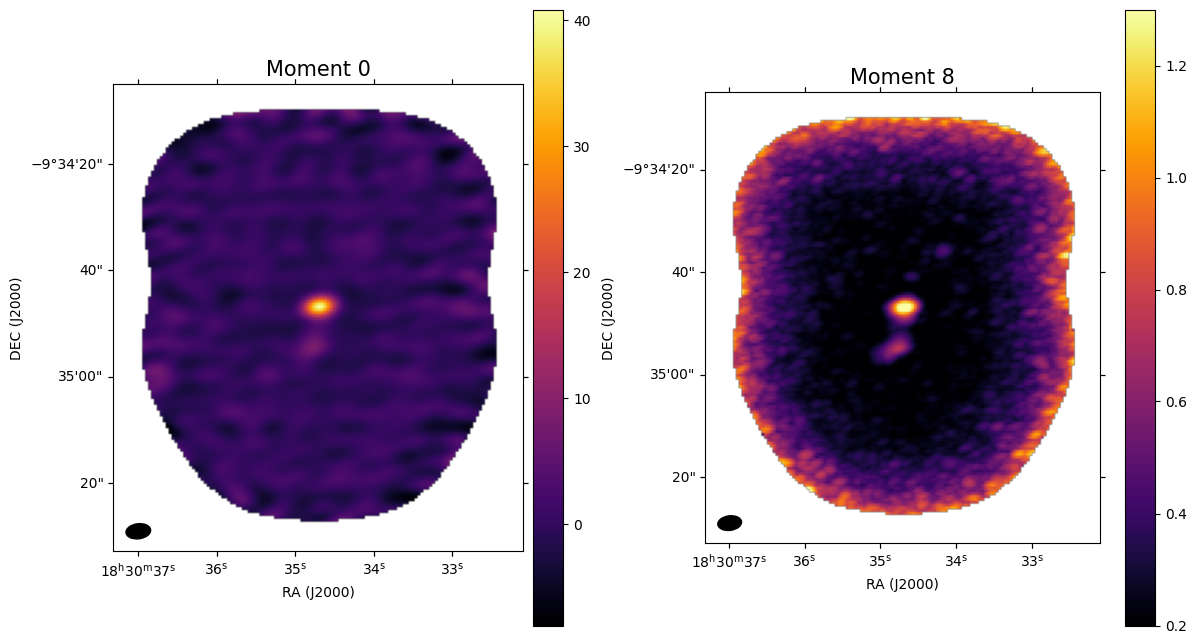

In [51]:
wcs_2d = mom0.wcs.celestial
fig = plt.figure(figsize=(14, 8))
ax0 = fig.add_subplot(1, 2, 1, projection=wcs_2d)
ax1 = fig.add_subplot(1, 2, 2, projection=wcs_2d)

img0= ax0.imshow(mom0.value, origin='lower',cmap = 'inferno')
img1 = ax1.imshow(mom8.value, origin='lower',cmap = 'inferno',vmin = 0.2, vmax = 1.3)

ax0.set_title('Moment 0',size = 15)
ax1.set_title('Moment 8',size = 15)
ax0.set_xlabel('RA (J2000)')
ax0.set_ylabel('DEC (J2000)')
ax1.set_xlabel('RA (J2000)')
ax1.set_ylabel('DEC (J2000)')
add_beam(ax0,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')

add_beam(ax1,
         header=cube.header,
         facecolor='black',
         edgecolor = 'black')
cbar0 = fig.colorbar(img0, ax = ax0, pad = 0.02)
cbar1 = fig.colorbar(img1, ax = ax1 )
#plt.savefig('NGC1333-IRAS2A_mom0_mom8_cube.png', dpi=300, bbox_inches='tight')
plt.show()